In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import utils as u
import numpy as np
from chroma_transformer import KeyLabelConverter
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import wilcoxon
plt.style.use('seaborn-v0_8')

/Users/jeffreygordon/Dev/School/MIR/mir-key-estimation/.venv/lib/python3.13/site-packages/madmom/processors.py:63: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  obj = pickle.load(f, encoding='latin1')


# Load data

In [3]:
fmak_metadata_df = pd.read_csv("data/fmak_v2.csv")

actual_keys_dict = {}

for _, row in fmak_metadata_df.iterrows():
    actual_keys_dict[row['track_id']] = u.normalize_key(row['key_and_mode'])

print(f"{len(actual_keys_dict)} actual keys loaded.")

5489 actual keys loaded.


In [4]:
krumhansl_df = pd.read_csv("baseline_hpc/krumhansl_predictions_full.csv")
krumhansl_keys_dict = {}

for _, row in krumhansl_df.iterrows():
    krumhansl_keys_dict[row['track_id']] = u.normalize_key(row['predicted_key'])

print(f"{len(krumhansl_keys_dict)} Krumhansl predictions loaded.")

5489 Krumhansl predictions loaded.


In [5]:
madmom_df = pd.read_csv("baseline_hpc/madmom_predictions_full.csv")
madmom_keys_dict = {}

for _, row in madmom_df.iterrows():
    madmom_keys_dict[row['track_id']] = u.normalize_key(row['predicted_key'])

print(f"{len(madmom_keys_dict)} Madmom predictions loaded.")

5489 Madmom predictions loaded.


In [6]:
track_ids = np.array(list(actual_keys_dict.keys()))
actual_keys = np.array([actual_keys_dict[tid] for tid in track_ids])
krumhansl_keys = np.array([krumhansl_keys_dict.get(tid) for tid in track_ids])
madmom_keys = np.array([madmom_keys_dict.get(tid) for tid in track_ids])

In [7]:
fma_tracks_df = pd.read_csv('data/fma_tracks.csv', index_col=0, header=[0, 1])
fmak_tracks_df = fma_tracks_df[fma_tracks_df.index.isin(track_ids)]

# EDA

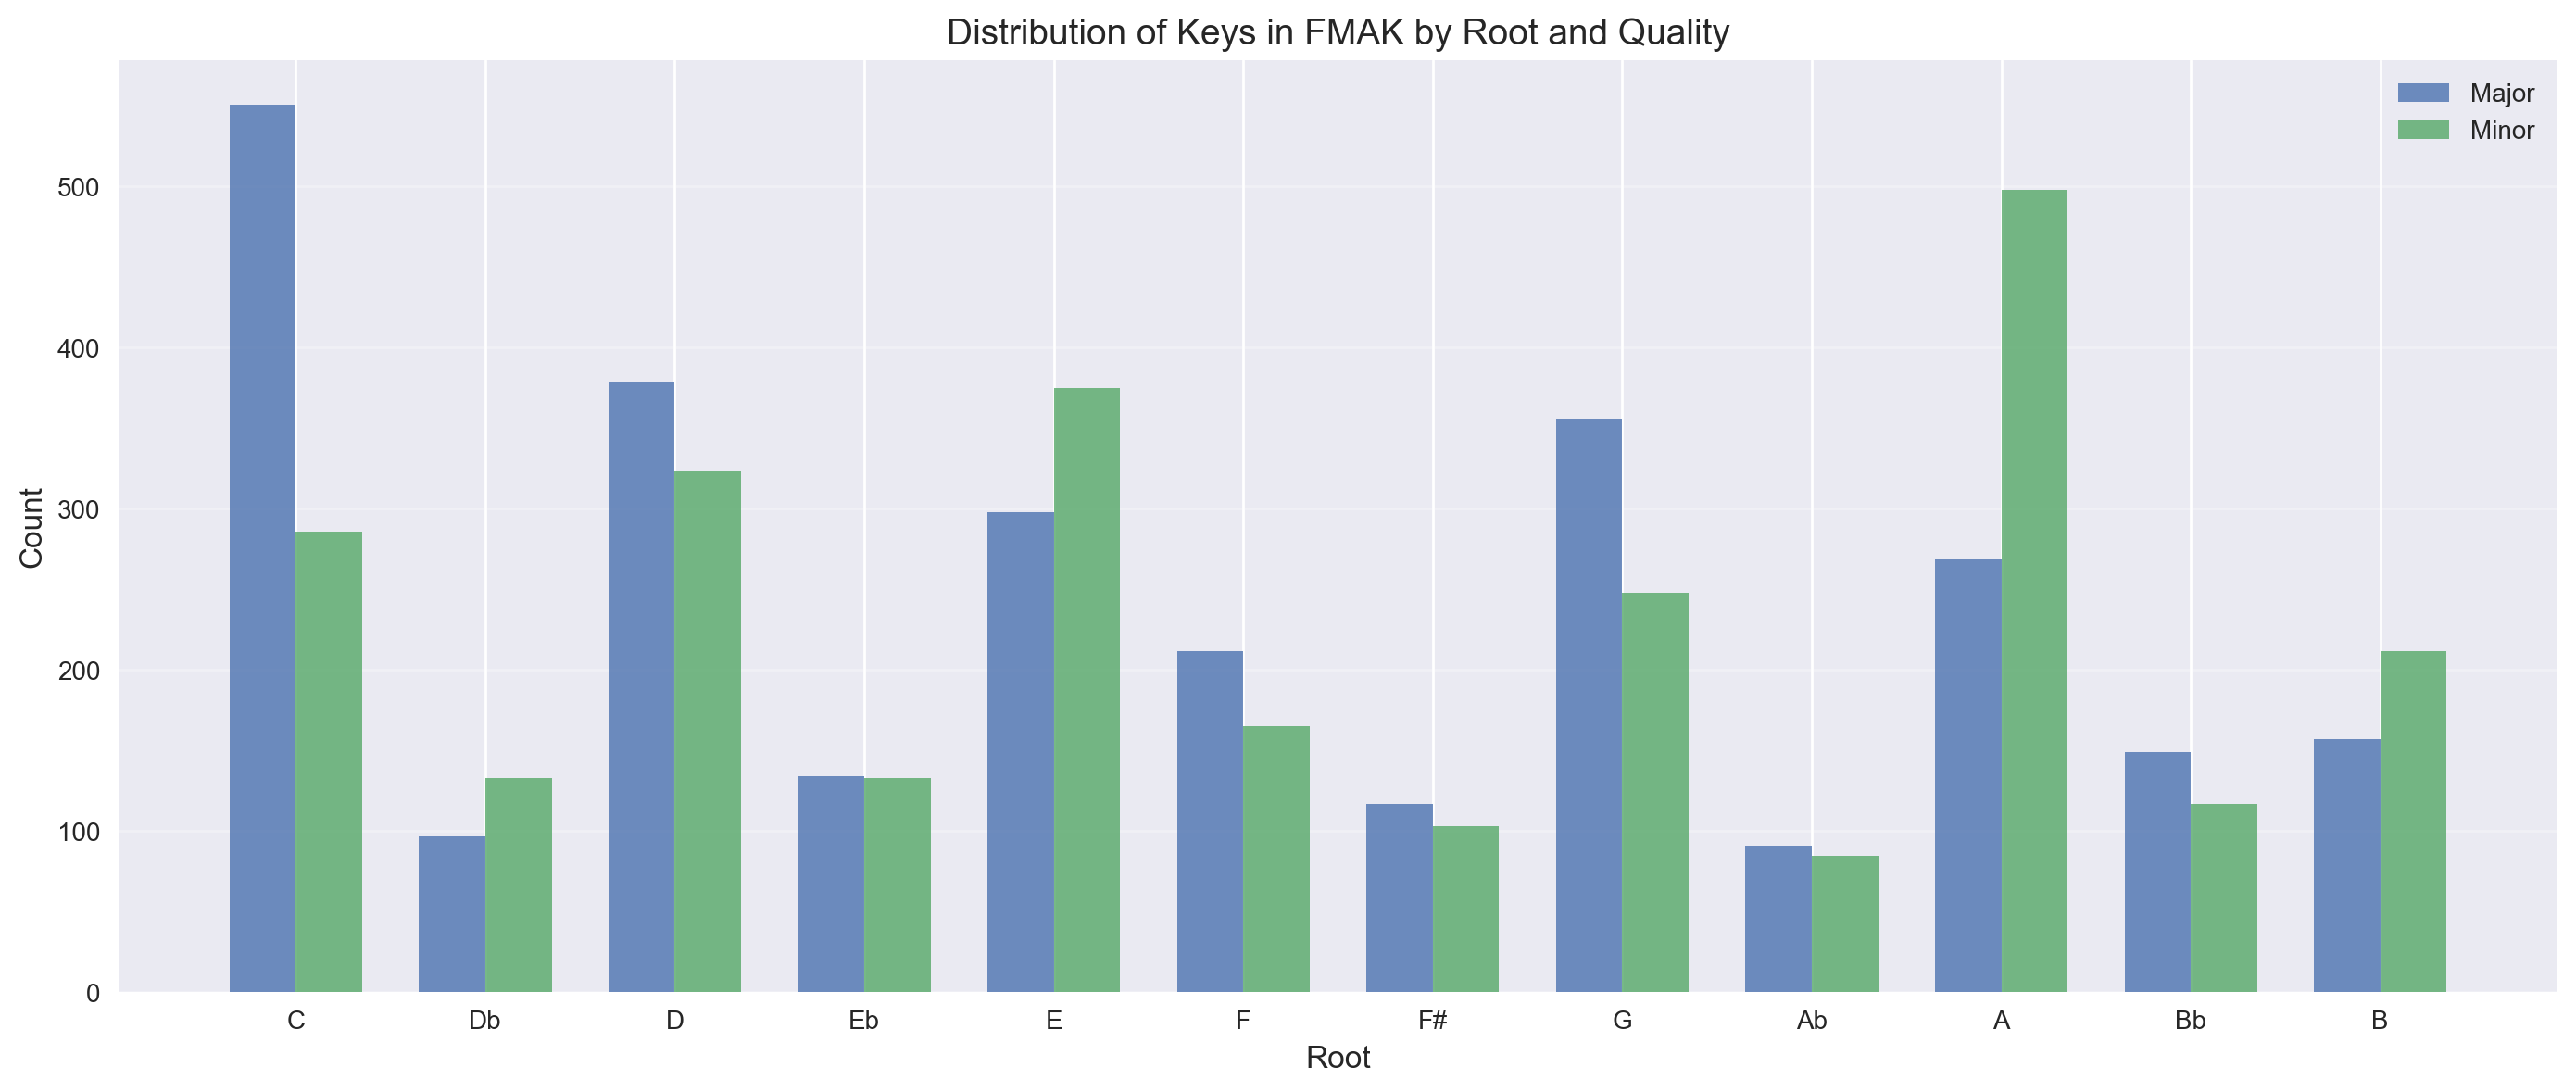

In [8]:
# Count major and minor for each root
key_counts = {root: {'major': 0, 'minor': 0} for root in u.ROOTS}

for key in actual_keys:
    parts = key.split()
    root = parts[0]
    mode = parts[1].lower()
    if root in key_counts:
        key_counts[root][mode] += 1

# Create bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(u.ROOTS))
width = 0.35

major_counts = [key_counts[root]['major'] for root in u.ROOTS]
minor_counts = [key_counts[root]['minor'] for root in u.ROOTS]

bars1 = ax.bar(x - width/2, major_counts, width, label='Major', alpha=0.8)
bars2 = ax.bar(x + width/2, minor_counts, width, label='Minor', alpha=0.8)

ax.set_xlabel('Root', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Keys in FMAK by Root and Quality', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(u.ROOTS)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

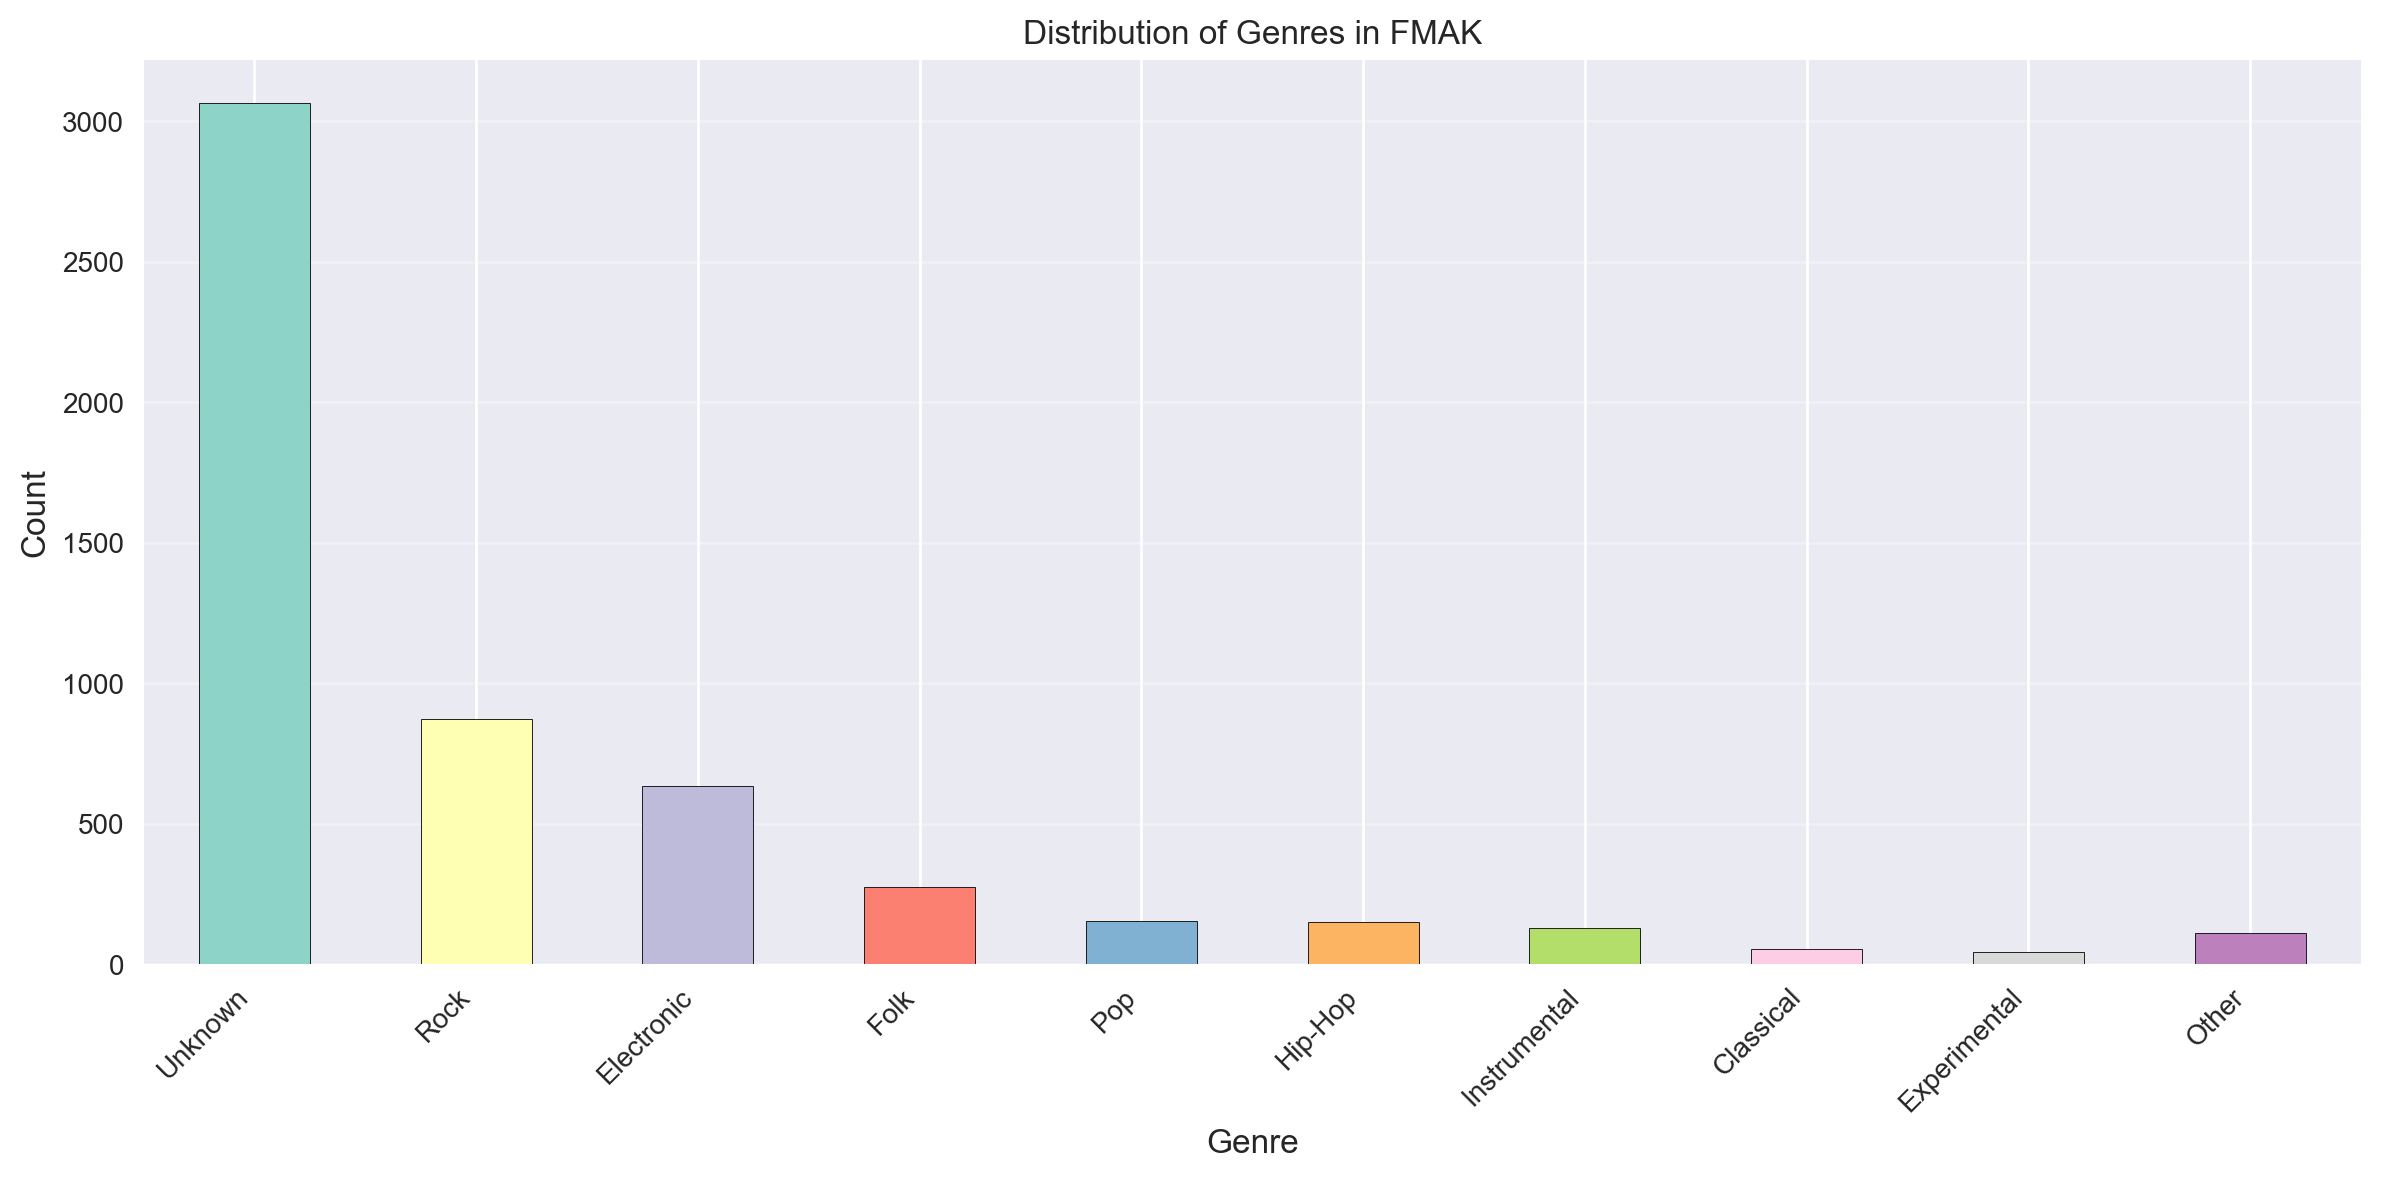

In [9]:
genres = fmak_tracks_df['track']['genre_top']
genres_filled = genres.fillna('Unknown')
genre_counts = genres_filled.value_counts()

# Get top 8 genres and bucket the rest as "Other"
top_8 = genre_counts.head(9)
other_count = genre_counts.iloc[9:].sum()
if other_count > 0:
    top_8['Other'] = other_count

plt.figure(figsize=(12, 6))
colors = plt.cm.Set3(range(len(top_8)))
top_8.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Distribution of Genres in FMAK')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Evaluate baseline methods on entire dataset

In [10]:
krumhansl_metrics = u.get_metrics(krumhansl_keys, actual_keys)
madmom_metrics = u.get_metrics(madmom_keys, actual_keys)

u.print_metrics(krumhansl_metrics, "Krumhansl")
print()
u.print_metrics(madmom_metrics, "Madmom")

=== Krumhansl ===
Accuracy: 0.5360
Precision (Macro): 0.5098
Recall (Macro): 0.5096
F1 Score (Macro): 0.5062
Average MIREX Score: 0.6154

=== Madmom ===
Accuracy: 0.6533
Precision (Macro): 0.6472
Recall (Macro): 0.6319
F1 Score (Macro): 0.6351
Average MIREX Score: 0.7111


# Aggregate across folds to compare with Chroma Transformer

In [11]:
def get_fold_track_ids(fold_num):
    fold_df = pd.read_csv(f"chroma_transformer/folds/fold_{fold_num:02d}/test.csv")
    return fold_df['track_id'].tolist()

all_fold_track_ids = [get_fold_track_ids(fold_num) for fold_num in range(10)]
print(f"Loaded {len(all_fold_track_ids)} fold track ID lists with lengths: {[len(ids) for ids in all_fold_track_ids]}")

Loaded 10 fold track ID lists with lengths: [549, 549, 549, 549, 549, 549, 549, 549, 549, 548]


In [12]:
def get_chroma_transformer_predictions(fold_num):
    import numpy as np
    pred_file = f"chroma_transformer/predictions/fold_{fold_num:02d}_predictions.npz"
    data = np.load(pred_file)
    predictions = data['y_pred']
    keys = [KeyLabelConverter.label_to_key(pred) for pred in predictions]
    normalized_keys = [u.normalize_key(key) for key in keys]
    fold_dict = {tid: key for tid, key in zip(all_fold_track_ids[fold_num], normalized_keys)}
    return fold_dict

def get_baseline_predictions(fold_num, baseline_keys_dict):
    fold_track_ids = all_fold_track_ids[fold_num]
    pred_dict = {tid: baseline_keys_dict.get(tid) for tid in fold_track_ids}
    return pred_dict

fold_chroma_transformer_keys = [get_chroma_transformer_predictions(fold_num) for fold_num in range(10)]
fold_krumhansl_keys = [get_baseline_predictions(fold_num, krumhansl_keys_dict) for fold_num in range(10)]
fold_madmom_keys = [get_baseline_predictions(fold_num, madmom_keys_dict) for fold_num in range(10)]
fold_actual_keys = [get_baseline_predictions(fold_num, actual_keys_dict) for fold_num in range(10)]

In [13]:
def print_fold_aggregated_metrics(fold_predicted_keys, name):
    metrics = []

    for fold_num in range(10):
        fold_track_ids = all_fold_track_ids[fold_num]
        true_keys = [fold_actual_keys[fold_num][track_id] for track_id in fold_track_ids]
        predicted_keys = [fold_predicted_keys[fold_num][track_id] for track_id in fold_track_ids]
        fold_metrics = u.get_metrics(predicted_keys, true_keys)
        metrics.append(fold_metrics)

    print(f"=== {name} Fold-Aggregated Metrics ===")
    for metric_name in metrics[0].keys():
        mu = np.mean([fold_metrics[metric_name] for fold_metrics in metrics])
        std = np.std([fold_metrics[metric_name] for fold_metrics in metrics])
        print(f"{metric_name}: {mu:.4f} ± {std:.4f}")

print_fold_aggregated_metrics(fold_krumhansl_keys, "Krumhansl")
print()
print_fold_aggregated_metrics(fold_madmom_keys, "Madmom")
print()
print_fold_aggregated_metrics(fold_chroma_transformer_keys, "Chroma Transformer")

=== Krumhansl Fold-Aggregated Metrics ===
Accuracy: 0.5360 ± 0.0212
Precision (Macro): 0.5077 ± 0.0244
Recall (Macro): 0.5078 ± 0.0236
F1 Score (Macro): 0.4977 ± 0.0232
Average MIREX Score: 0.6154 ± 0.0198

=== Madmom Fold-Aggregated Metrics ===
Accuracy: 0.6533 ± 0.0219
Precision (Macro): 0.6455 ± 0.0186
Recall (Macro): 0.6347 ± 0.0245
F1 Score (Macro): 0.6294 ± 0.0205
Average MIREX Score: 0.7111 ± 0.0192

=== Chroma Transformer Fold-Aggregated Metrics ===
Accuracy: 0.6316 ± 0.0271
Precision (Macro): 0.6063 ± 0.0335
Recall (Macro): 0.6053 ± 0.0328
F1 Score (Macro): 0.5967 ± 0.0347
Average MIREX Score: 0.6919 ± 0.0240


In [14]:
def get_fold_scores(fold_predicted_keys, metric='Average MIREX Score'):
    scores = []
    for fold_num in range(10):
        fold_track_ids = all_fold_track_ids[fold_num]
        true_keys = [fold_actual_keys[fold_num][tid] for tid in fold_track_ids]
        predicted_keys = [fold_predicted_keys[fold_num][tid] for tid in fold_track_ids]
        scores.append(u.get_metrics(predicted_keys, true_keys)[metric])
    return np.array(scores)

ct_scores = get_fold_scores(fold_chroma_transformer_keys)
madmom_scores = get_fold_scores(fold_madmom_keys)
krumhansl_scores = get_fold_scores(fold_krumhansl_keys)

stat, p = wilcoxon(ct_scores, madmom_scores)
print(f"Chroma Transformer vs Madmom (Wilcoxon signed-rank): statistic={stat:.1f}, p={p:.4f}")

stat, p = wilcoxon(krumhansl_scores, madmom_scores)
print(f"Krumhansl vs Madmom (Wilcoxon signed-rank): statistic={stat:.1f}, p={p:.4f}")


Chroma Transformer vs Madmom (Wilcoxon signed-rank): statistic=5.0, p=0.0195
Krumhansl vs Madmom (Wilcoxon signed-rank): statistic=0.0, p=0.0020


# Key Distance

In [15]:
# Treat chroma transformer folds as a single set of predictions across entire dataset
chroma_transformer_keys_dict = {}

for fold_num in range(10):
    fold_keys = fold_chroma_transformer_keys[fold_num]
    chroma_transformer_keys_dict.update(fold_keys)

chroma_transformer_keys = [chroma_transformer_keys_dict[tid] for tid in track_ids]

In [16]:
krumhansl_key_distances = [u.get_key_distance(pred, actual) for pred, actual in zip(krumhansl_keys, actual_keys)]
madmom_key_distances = [u.get_key_distance(pred, actual) for pred, actual in zip(madmom_keys, actual_keys)]
chroma_transformer_key_distances = [u.get_key_distance(pred, actual) for pred, actual in zip(chroma_transformer_keys, actual_keys)]

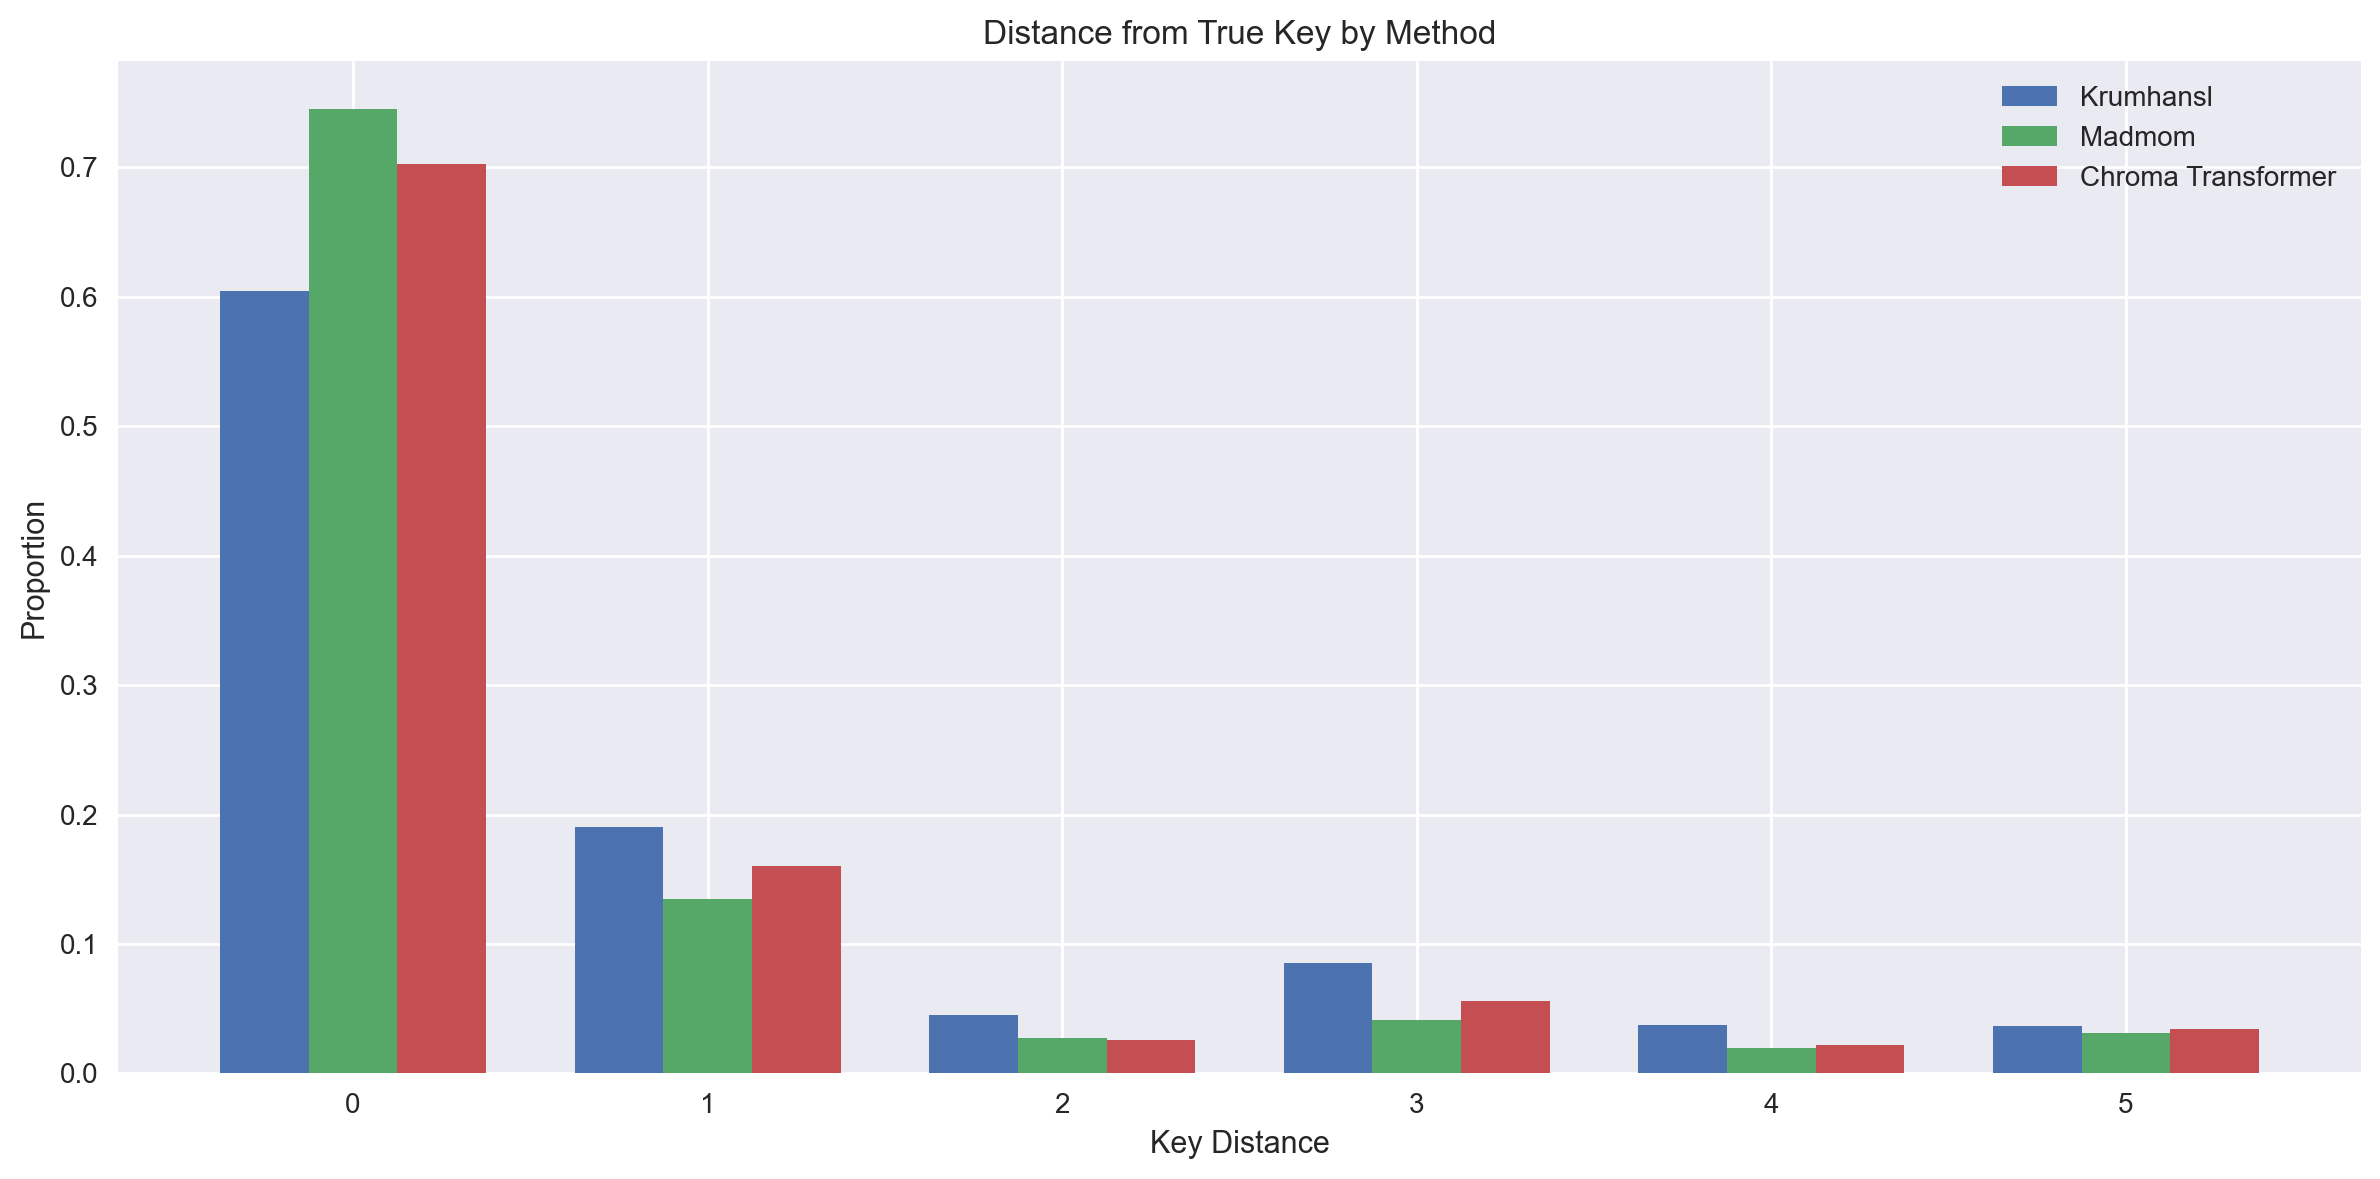

In [17]:
# Calculate key distance distributions
krumhansl_dist_counter = Counter(krumhansl_key_distances)
madmom_dist_counter = Counter(madmom_key_distances)
chroma_transformer_dist_counter = Counter(chroma_transformer_key_distances)

# Get all unique distances sorted
all_distances = sorted(set(krumhansl_key_distances) | set(madmom_key_distances) | set(chroma_transformer_key_distances))

# Convert to proportions
total = len(krumhansl_key_distances)
krumhansl_proportions = [krumhansl_dist_counter.get(d, 0) / total for d in all_distances]
madmom_proportions = [madmom_dist_counter.get(d, 0) / total for d in all_distances]
chroma_transformer_proportions = [chroma_transformer_dist_counter.get(d, 0) / total for d in all_distances]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_distances))
width = 0.25

ax.bar(x - width, krumhansl_proportions, width, label='Krumhansl')
ax.bar(x, madmom_proportions, width, label='Madmom')
ax.bar(x + width, chroma_transformer_proportions, width, label='Chroma Transformer')

ax.set_xlabel('Key Distance')
ax.set_ylabel('Proportion')
ax.set_title('Distance from True Key by Method')
ax.set_xticks(x)
ax.set_xticklabels(all_distances)
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
print("== Krumhansl ==")
print(f"Relative Key Error Proportion: {u.get_relative_key_error_proportion(krumhansl_keys, actual_keys):.4f}")
print(f"Parallel Key Error Proportion: {u.get_parallel_key_error_proportion(krumhansl_keys, actual_keys):.4f}")
print()
print("== Madmom ==")
print(f"Relative Key Error Proportion: {u.get_relative_key_error_proportion(madmom_keys, actual_keys):.4f}")
print(f"Parallel Key Error Proportion: {u.get_parallel_key_error_proportion(madmom_keys, actual_keys):.4f}")
print()
print("== Chroma Transformer ==")
print(f"Relative Key Error Proportion: {u.get_relative_key_error_proportion(chroma_transformer_keys, actual_keys):.4f}")
print(f"Parallel Key Error Proportion: {u.get_parallel_key_error_proportion(chroma_transformer_keys, actual_keys):.4f}")

== Krumhansl ==
Relative Key Error Proportion: 0.1480
Parallel Key Error Proportion: 0.1516

== Madmom ==
Relative Key Error Proportion: 0.2648
Parallel Key Error Proportion: 0.0867

== Chroma Transformer ==
Relative Key Error Proportion: 0.1919
Parallel Key Error Proportion: 0.1256


# Qualitative Evaluation

In [19]:
# find track IDs where all three methods got the key wrong
wrong_track_ids = []

for tid in track_ids:
    if tid >= 20_000:
        continue # skip tracks not in the locally downloaded subset
    if (krumhansl_keys_dict.get(tid) != actual_keys_dict[tid] and
        madmom_keys_dict.get(tid) != actual_keys_dict[tid] and
        chroma_transformer_keys_dict.get(tid) != actual_keys_dict[tid]):
        wrong_track_ids.append(tid)

In [20]:
for tid in wrong_track_ids[:10]:
    print(f"Track ID: {tid}")
    print(f"Actual Key: {actual_keys_dict[tid]}")
    print(f"Krumhansl Predicted Key: {krumhansl_keys_dict.get(tid)}")
    print(f"Madmom Predicted Key: {madmom_keys_dict.get(tid)}")
    print(f"Chroma Transformer Predicted Key: {chroma_transformer_keys_dict.get(tid)}")
    print()

Track ID: 153
Actual Key: Db major
Krumhansl Predicted Key: E major
Madmom Predicted Key: E major
Chroma Transformer Predicted Key: Db minor

Track ID: 173
Actual Key: A major
Krumhansl Predicted Key: B major
Madmom Predicted Key: B major
Chroma Transformer Predicted Key: E major

Track ID: 181
Actual Key: G major
Krumhansl Predicted Key: B minor
Madmom Predicted Key: B major
Chroma Transformer Predicted Key: B minor

Track ID: 411
Actual Key: G minor
Krumhansl Predicted Key: G major
Madmom Predicted Key: G major
Chroma Transformer Predicted Key: G major

Track ID: 532
Actual Key: Eb major
Krumhansl Predicted Key: Db major
Madmom Predicted Key: Eb minor
Chroma Transformer Predicted Key: Ab minor

Track ID: 533
Actual Key: G minor
Krumhansl Predicted Key: F minor
Madmom Predicted Key: F minor
Chroma Transformer Predicted Key: F major

Track ID: 535
Actual Key: F# major
Krumhansl Predicted Key: B major
Madmom Predicted Key: B major
Chroma Transformer Predicted Key: B major

Track ID: 540